In [2]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
import mpl_toolkits
mpl.style.use("fivethirtyeight")
import plotly.offline as py
import plotly.graph_objects as go
import plotly.tools as tls

In [4]:
matches=pd.read_csv("matches.csv")
delivery=pd.read_csv("delivery.csv")

In [55]:
matches.head()

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,2017,Hyderabad,5/4/2017,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
1,2,2017,Pune,6/4/2017,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN
2,3,2017,Rajkot,7/4/2017,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN
3,4,2017,Indore,8/4/2017,Rising Pune Supergiant,Punjab Kings,Kings XI Punjab,field,normal,0,Punjab Kings,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN
4,5,2017,Bangalore,8/4/2017,Royal Challengers Bangalore,Delhi Capitals,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN


In [56]:
delivery.head()

,ID,innings,overs,ballnumber,batter,bowler,non-striker,extra_type,batsman_run,extras_run,total_run,non_boundary,isWicketDelivery,player_out,kind,fielders_involved,BattingTeam,total_runs,match_id
0,1312200,1,0,1,YBK Jaiswal,Mohammed Shami,JC Buttler,NaN,0,0,0,0,0,NaN,NaN,NaN,Rajasthan Royals,0,950
1,1312200,1,0,2,YBK Jaiswal,Mohammed Shami,JC Buttler,legbyes,0,1,1,0,0,NaN,NaN,NaN,Rajasthan Royals,1,950
2,1312200,1,0,3,JC Buttler,Mohammed Shami,YBK Jaiswal,NaN,1,0,1,0,0,NaN,NaN,NaN,Rajasthan Royals,1,950
3,1312200,1,0,4,YBK Jaiswal,Mohammed Shami,JC Buttler,NaN,0,0,0,0,0,NaN,NaN,NaN,Rajasthan Royals,0,950
4,1312200,1,0,5,YBK Jaiswal,Mohammed Shami,JC Buttler,NaN,0,0,0,0,0,NaN,NaN,NaN,Rajasthan Royals,0,950


### Missing values

In [11]:
print(matches.isnull().sum())

id                   0
season               0
city                 7
date                 0
team1                0
team2                0
toss_winner          0
toss_decision        0
result               0
dl_applied           0
winner               3
win_by_runs          0
win_by_wickets       0
player_of_match      3
venue                0
umpire1              1
umpire2              1
umpire3            636
dtype: int64


In [12]:
print(delivery.isnull().sum())

ID                        0
innings                   0
overs                     0
ballnumber                0
batter                    0
bowler                    0
non-striker               0
extra_type           213905
batsman_run               0
extras_run                0
total_run                 0
non_boundary              0
isWicketDelivery          0
player_out           214803
kind                 214803
fielders_involved    217966
BattingTeam               0
dtype: int64


### Standardize Team Names

In [13]:
matches['team1'] = matches['team1'].replace({'Delhi Daredevils':'Delhi Capitals','Kings XI Punjab':'Punjab Kings'})
matches['team2'] = matches['team2'].replace({'Delhi Daredevils':'Delhi Capitals','Kings XI Punjab':'Punjab Kings'})
matches['winner'] = matches['winner'].replace({'Delhi Daredevils':'Delhi Capitals','Kings XI Punjab':'Punjab Kings'})

### Winner Prediction by Year

In [14]:
wins_per_season = matches.groupby(['season','winner']).size().reset_index(name='wins')
wins_per_season.head()

,season,winner,wins
0,2008,Chennai Super Kings,9
1,2008,Deccan Chargers,2
2,2008,Delhi Capitals,7
3,2008,Kolkata Knight Riders,6
4,2008,Mumbai Indians,7


### Plot Wins per Team

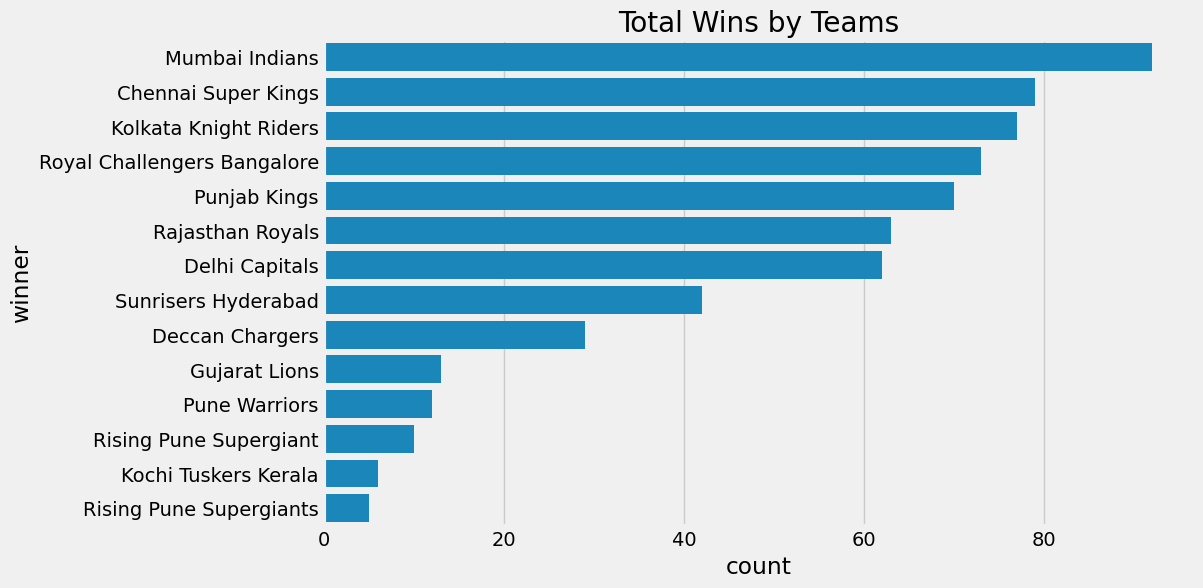

In [15]:
plt.figure(figsize=(10,6))
sns.countplot(y='winner', data=matches, order=matches['winner'].value_counts().index)
plt.title("Total Wins by Teams")
plt.show()

### Super Over Analysis

In [16]:
super_over_matches = matches[matches['result'] == 'tie']
print(super_over_matches[['season','team1','team2','winner']])

     season                        team1                        team2  \
33     2017                Gujarat Lions               Mumbai Indians   
125    2009             Rajasthan Royals        Kolkata Knight Riders   
189    2010                 Punjab Kings          Chennai Super Kings   
387    2013  Royal Challengers Bangalore          Sunrisers Hyderabad   
400    2013               Delhi Capitals  Royal Challengers Bangalore   
475    2014             Rajasthan Royals        Kolkata Knight Riders   
535    2015             Rajasthan Royals                 Punjab Kings   

                          winner  
33                Mumbai Indians  
125             Rajasthan Royals  
189                 Punjab Kings  
387          Sunrisers Hyderabad  
400  Royal Challengers Bangalore  
475             Rajasthan Royals  
535                 Punjab Kings  


### Favorite Umpire Trends

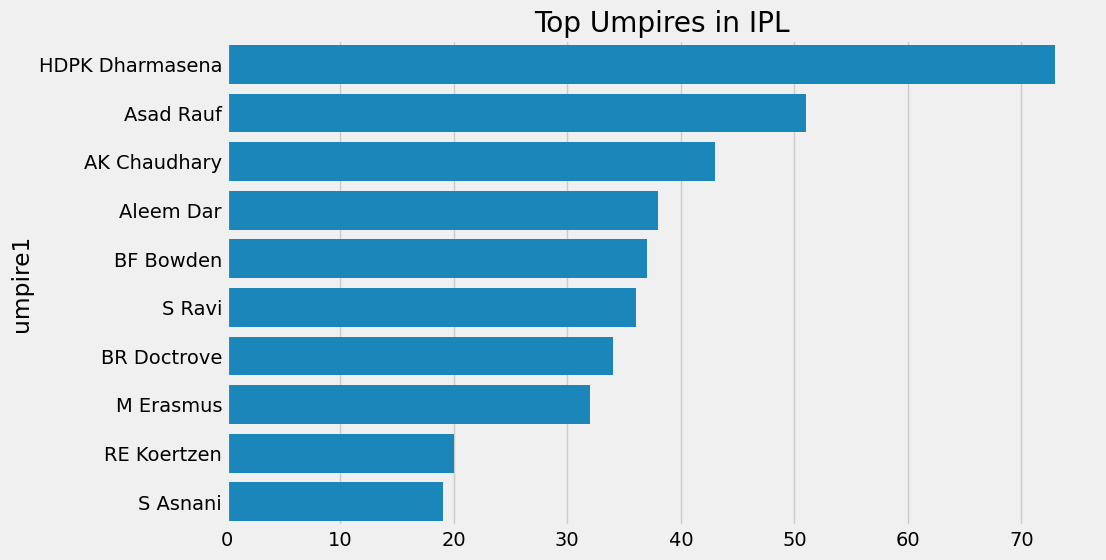

In [17]:
umpire_count = matches['umpire1'].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=umpire_count.values, y=umpire_count.index)
plt.title("Top Umpires in IPL")
plt.show()

### High Scoring Matches (200+ Runs)

In [34]:
delivery['total_runs'] = delivery['batsman_run'] + delivery['extras_run']

### Total Score per Match

In [36]:
delivery["match_id"]=delivery["ID"].astype('category').cat.codes+1

In [37]:
match_runs = delivery.groupby('match_id')['total_run'].sum().reset_index()
high_scoring = match_runs[match_runs['total_run'] >= 200]
print(high_scoring.head())

   match_id  total_run
0         1        304
1         2        447
2         3        261
3         4        331
4         5        222


### Top Batsmen (Player Batting Stats)

In [39]:
top_batsman = delivery.groupby('batter')['batsman_run'].sum().sort_values(ascending=False).head(10)
top_batsman

batter
V Kohli           6634
S Dhawan          6244
DA Warner         5883
RG Sharma         5881
SK Raina          5536
AB de Villiers    5181
CH Gayle          4997
MS Dhoni          4978
RV Uthappa        4954
KD Karthik        4377
Name: batsman_run, dtype: int64

### Plot Top Batsmen

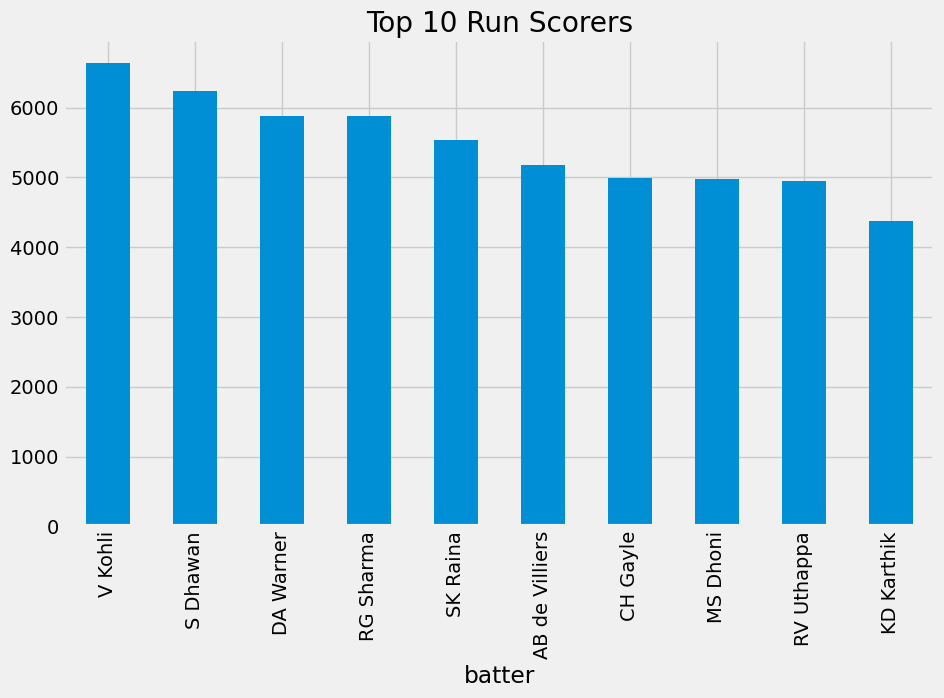

In [40]:
plt.figure(figsize=(10,6))
top_batsman.plot(kind='bar')
plt.title("Top 10 Run Scorers")
plt.show()

### Top Bowlers (Wicket Takers)

In [42]:
wickets = delivery[delivery['isWicketDelivery']==1]

top_bowlers = wickets.groupby('bowler').size().sort_values(ascending=False).head(10)
top_bowlers

bowler
DJ Bravo           207
SL Malinga         188
A Mishra           175
R Ashwin           174
YS Chahal          172
SP Narine          171
PP Chawla          165
B Kumar            165
JJ Bumrah          161
Harbhajan Singh    161
dtype: int64

### Plot Top Bowlers

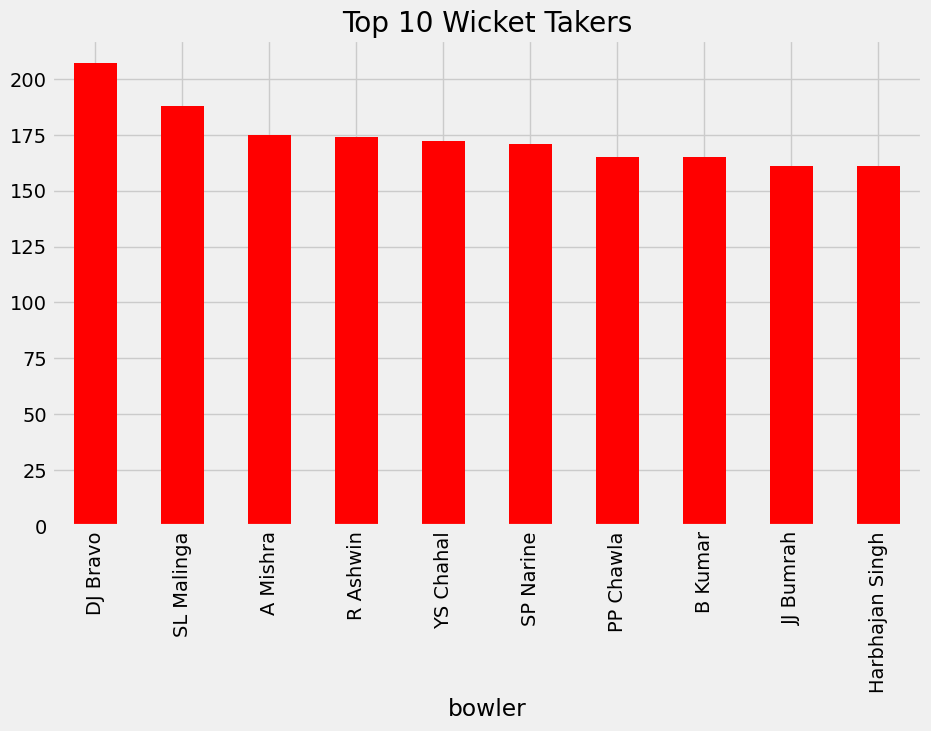

In [43]:
plt.figure(figsize=(10,6))
top_bowlers.plot(kind='bar',color='red')
plt.title("Top 10 Wicket Takers")
plt.show()

### Orange Cap (Most Runs per Season)

In [45]:
season_runs = delivery.merge(matches[['id','season']], left_on='match_id', right_on='id')

orange_cap = season_runs.groupby(['season','batter'])['batsman_run'].sum().reset_index()
orange_cap = orange_cap.sort_values(['season','batsman_run'],ascending=[True,False])

orange_cap.groupby('season').first()

,batter,batsman_run
season,,
2008,AC Gilchrist,549
2009,JH Kallis,572
2010,SR Tendulkar,456
2011,CH Gayle,744
2012,MEK Hussey,760
2013,DR Smith,721
2014,DA Warner,562
2015,V Kohli,919
2016,DA Warner,710


### Purple Cap (Most Wickets per Season)

In [46]:
season_wickets = wickets.merge(matches[['id','season']], left_on='match_id', right_on='id')

purple_cap = season_wickets.groupby(['season','bowler']).size().reset_index(name='wickets')
purple_cap = purple_cap.sort_values(['season','wickets'],ascending=[True,False])

purple_cap.groupby('season').first()

,bowler,wickets
season,,
2008,RP Singh,27
2009,PP Ojha,22
2010,SL Malinga,29
2011,M Morkel,25
2012,DJ Bravo,30
2013,MM Sharma,33
2014,DJ Bravo,28
2015,B Kumar,23
2016,B Kumar,29


### Player Comparison (Example)

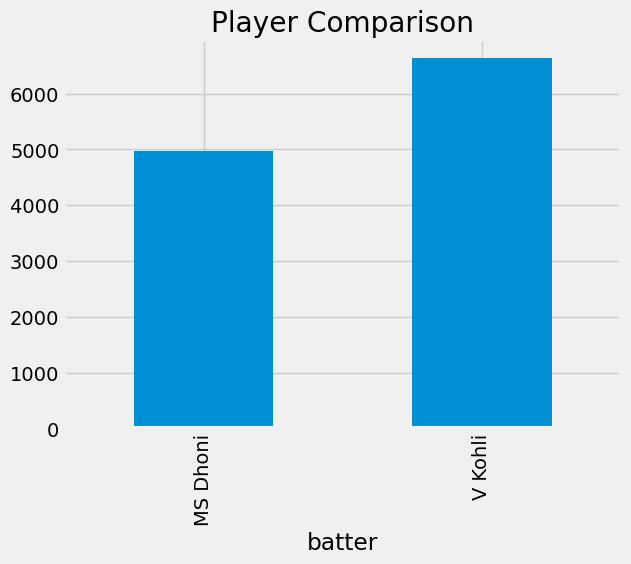

In [49]:
players = delivery[delivery['batter'].isin(['V Kohli','MS Dhoni'])]

player_runs = players.groupby('batter')['batsman_run'].sum()

player_runs.plot(kind='bar',title="Player Comparison")
plt.show()

### Prepare Data for Prediction

In [50]:
from sklearn.preprocessing import LabelEncoder

df = matches[['team1','team2','toss_winner','toss_decision','winner']].dropna()

le = LabelEncoder()

for col in df.columns:
    df[col] = le.fit_transform(df[col])

### Train Prediction Model

In [51]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X = df[['team1','team2','toss_winner','toss_decision']]
y = df['winner']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

model = RandomForestClassifier()
model.fit(X_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### Prediction Accuracy

In [52]:
from sklearn.metrics import accuracy_score

pred = model.predict(X_test)

print("Accuracy:",accuracy_score(y_test,pred))

Accuracy: 0.5354330708661418


### Example Match Prediction

In [54]:
sample = X_test.iloc[0:1]
prediction = model.predict(sample)

print("Predicted Winner:",prediction)

Predicted Winner: [1]
